# **Table of Contents**
* [Your Notebook](#your-notebook)
  * [Table of Contents](#table-of-contents)
* [TOC Generator](#toc-generator)


imports

In [ ]:
import pandas as pd
import geopandas as gpd

## Clean Poverty Data

In [ ]:
df_poverty = pd.read_csv('../Curtis/data/raw/acs_2024_jefferson_poverty_by_tract_s1701.csv')

df_poverty.columns

In [ ]:
df_poverty = df_poverty[["GEO_ID", "NAME", "S1701_C01_001E", "S1701_C02_001E", "S1701_C03_001E"]]

# The first row labels are redundant
df_poverty.drop(index = 0, inplace = True)

# Rename to useful column names
df_poverty = df_poverty.rename(columns={
    "NAME" : "TRACT",
    "S1701_C01_001E" : "POPULATION",
    "S1701_C02_001E" : "BELOW_POVERTY",
    "S1701_C03_001E" : "POVERTY_RATE"
    })

# Keep only tract # in string
df_poverty['TRACT'] = df_poverty['TRACT'].str.extract(r'Census Tract ([\d.]+)')

# Treat Tract # as a float for merging later (hold if needed)
# df_poverty['TRACT'] = df_poverty['TRACT'].astype(float)

df_poverty.head()

In [ ]:
# Output clean file
df_poverty.to_csv("../Curtis/data/processed/poverty_rate_clean.csv", index = False)

## Clean Income Data

In [ ]:
df_income = pd.read_csv('../Curtis/data/raw/acs_2024_jefferson_household_income_by_tract_b19013.csv')

df_income.head()

In [ ]:
# Rename columns
df_income = df_income.rename(columns={
    "Label (Grouping)" : "TRACT",
    "Median household income in the past 12 months (in 2024 inflation-adjusted dollars)" : "ESTIMATED_MEDIAN_HOUSEHOLD_INCOME"
    })

df_income.head()

In [ ]:
# Shift values up one row so Estimate will be on the same row as tract
df_income['ESTIMATED_MEDIAN_HOUSEHOLD_INCOME'] = df_income['ESTIMATED_MEDIAN_HOUSEHOLD_INCOME'].shift(-1)

df_income.head()

In [ ]:
# Simplify the layout to be "Tract #: Estimate value" and delete Margin of Error rows
df_income = df_income.drop(df_income[df_income['TRACT'].str.contains('Estimate|Margin of Error', na=False)].index)

# Keep only tract # in string
df_income['TRACT'] = df_income['TRACT'].str.extract(r'Census Tract ([\d.]+)')

# Treat Tract # as a float for merging later (hold if needed)
# df_income['TRACT'] = df_income['TRACT'].astype(float)

df_income.head()

In [ ]:
# Output clean file
df_income.to_csv("../Curtis/data/processed/income_clean.csv", index = True)

## Clean Housing Age Data

In [ ]:
df_housing_age = pd.read_csv('../Curtis/data/raw/acs_2024_jefferson_housing_age_by_tract_b25034.csv')

df_housing_age.head()

In [ ]:
# Drop all Estimate columns
cols_to_drop_housing_age = df_housing_age.columns[df_housing_age.columns.str.contains('Margin of Error')]
df_housing_age = df_housing_age.drop(columns=cols_to_drop_housing_age)

df_housing_age.head()

In [ ]:
# Swap columns and rows to match other data sets
df_housing_age = df_housing_age.transpose()

# Set the first row as the header
df_housing_age = df_housing_age.rename(columns=df_housing_age.iloc[0]).drop(df_housing_age.index[0])

df_housing_age.head()

In [ ]:
# Remove the spaces before "Built" from all column names
df_housing_age.columns = df_housing_age.columns.str.strip()

# Remove the colon from "Total:"
df_housing_age.rename(columns={'Total:': 'TOTAL'}, inplace=True)

# Create index column
df_housing_age = df_housing_age.reset_index() 

# Now we can label first column
df_housing_age.rename(columns={df_housing_age.columns[0]: 'TRACT'}, inplace=True)

# Keep only tract # in string
df_housing_age['TRACT'] = df_housing_age['TRACT'].str.extract(r'Census Tract ([\d.]+)')

df_housing_age.head()

In [ ]:
# Output clean file
df_housing_age.to_csv("../Curtis/data/processed/housing_age_clean.csv", index = True)

## Clean Median Gross Rent

In [ ]:
df_rent = pd.read_csv('../Curtis/data/raw/acs_2024_jefferson_median_gross_rent_by_tract_b25064.csv')

df_rent.head()

In [ ]:
# Drop all Estimate columns
cols_to_drop_rent = df_rent.columns[df_rent.columns.str.contains('Margin of Error')]
df_rent = df_rent.drop(columns=cols_to_drop_rent)

# Swap columns and rows to match other data sets
df_rent = df_rent.transpose()

df_rent.head()

In [ ]:
df_rent = df_rent.reset_index()

# Set the first row as the header
df_rent = df_rent.rename(columns=df_rent.iloc[0]).drop(df_rent.index[0])

df_rent.rename(columns={'Median gross rent' : 'MEDIAN_GROSS_RENT'}, inplace = True)

df_rent.head()

In [ ]:
# Now we can label first column
df_rent.rename(columns={df_rent.columns[0]: 'TRACT'}, inplace=True)

# Keep only tract # in string
df_rent['TRACT'] = df_rent['TRACT'].str.extract(r'Census Tract ([\d.]+)')

df_rent.head()


In [ ]:
# Output clean file
df_rent.to_csv("../Curtis/data/processed/rent_clean.csv", index = True)

## Clean Home Value

In [ ]:
df_home_value = pd.read_csv('../Curtis/data/raw/acs_2024_jefferson_median_home_value_by_tract_b25077.csv')

df_home_value.head()

In [ ]:
# Drop all Estimate columns
cols_to_drop_rent = df_home_value.columns[df_home_value.columns.str.contains('Margin of Error')]
df_home_value = df_home_value.drop(columns=cols_to_drop_rent)

# Swap columns and rows to match other data sets
df_home_value = df_home_value.transpose()

df_home_value.head()

In [ ]:
df_home_value = df_home_value.reset_index()

# Set the first row as the header
df_home_value = df_home_value.rename(columns=df_home_value.iloc[0]).drop(df_home_value.index[0])

df_home_value.rename(columns={'Median gross rent' : 'MEDIAN_GROSS_RENT'}, inplace = True)

df_home_value.head()

In [ ]:
# Now we can label first column
df_home_value.rename(columns={df_home_value.columns[0]: 'TRACT'}, inplace=True)

# Keep only tract # in string
df_home_value['TRACT'] = df_home_value['TRACT'].str.extract(r'Census Tract ([\d.]+)')

df_home_value.head()

In [ ]:
# Output clean file
df_rent.to_csv("../Curtis/data/processed/home_value_clean.csv", index = True)

## Clean Rent Burden

In [ ]:
df_rent_burden = pd.read_csv('../Curtis/data/raw/acs_2024_jefferson_rent_burden_by_tract_b25070.csv')

df_rent_burden.head(11)

In [ ]:
# Drop all Estimate columns
cols_to_drop_rent_burden = df_rent_burden.columns[df_rent_burden.columns.str.contains('Margin of Error')]
df_rent_burden = df_rent_burden.drop(columns=cols_to_drop_rent_burden)

df_rent_burden.head()

In [ ]:
# Swap columns and rows to match other data sets
df_rent_burden = df_rent_burden.transpose()

# Set the first row as the header
df_rent_burden = df_rent_burden.rename(columns=df_rent_burden.iloc[0]).drop(df_rent_burden.index[0])

df_rent_burden.head()

In [ ]:
# Remove the white spaces from all column names
df_rent_burden.columns = df_rent_burden.columns.str.strip()

# Remove the colon from "Total:"
df_rent_burden.rename(columns={'Total:': 'TOTAL'}, inplace=True)

# Create index column
df_rent_burden = df_rent_burden.reset_index() 

# Now we can label first column
df_rent_burden.rename(columns={df_rent_burden.columns[0]: 'TRACT'}, inplace=True)

# Keep only tract # in string
df_rent_burden['TRACT'] = df_rent_burden['TRACT'].str.extract(r'Census Tract ([\d.]+)')

df_rent_burden.head()

In [ ]:
# Output clean file
df_rent_burden.to_csv("../Curtis/data/processed/rent_burden_clean.csv", index = True)

## Clean Active Permits

In [ ]:
df_permits = pd.read_csv('../Curtis/data/raw/louisville_active_construction_permits.csv')

df_permits.head()

In [ ]:
df_permits.info()

In [ ]:
df_permits.isnull().sum()

In [ ]:
# Remove anything after the first 5 digits from ZIPCODE
df_permits["ZIPCODE"] = df_permits["ZIPCODE"].str.split("-").str[0]

df_permits["ZIPCODE"].head()

In [ ]:
# Columns to keep
df_permits = df_permits[['ISSUE_DATE', 'ADDRESS', 'CITY', 'ZIPCODE', 'LATITUDE', 'LONGITUDE', 'DISTRICT', 'NEIGHBORHOOD']]

df_permits.head()

In [ ]:
# Converting to datetime to pull 2024 data specifically
df_permits['ISSUE_DATE'] = pd.to_datetime(df_permits['ISSUE_DATE'])

df_permits.info()

In [ ]:
# Use 2024 to keep in line with the rest of the project
permits_2024 = (df_permits['ISSUE_DATE'] >= '1/01/2024') & (df_permits['ISSUE_DATE'] <= '12/31/2024')
df_permits = df_permits.loc[permits_2024]

df_permits.head()

In [59]:
df_permits.shape

(3336, 8)

In [ ]:
# Using geopandas to fill in the missing neighborhood data
neighborhoods = gpd.read_file("../Curtis/data/raw/louisville_neighborhoods.shp")

neighborhoods.head()

In [ ]:
neighborhoods.columns

In [ ]:
neighborhoods.crs

In [ ]:
# Set a Coordinate Reference System (CRS) - only if needed
# EPSG:2246 is Kentucky North
#neighborhoods = neighborhoods.set_crs("EPSG:2246")

In [ ]:
# Convert to latitude and logitude
neighborhoods = neighborhoods.to_crs("EPSG:4326")

In [ ]:
# Check to make sure it worked
neighborhoods.head()

<Axes: >

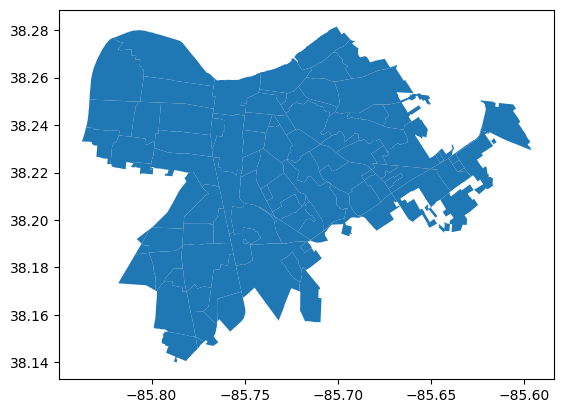

In [57]:
# Check to see if the map works
neighborhoods.plot()

In [58]:
df_permits.columns

Index(['ISSUE_DATE', 'ADDRESS', 'CITY', 'ZIPCODE', 'LATITUDE', 'LONGITUDE',
       'DISTRICT', 'NEIGHBORHOOD'],
      dtype='object')

In [ ]:
# Convert to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_permits,
    geometry=gpd.points_from_xy(df_permits["LONGITUDE"], df_permits["LATITUDE"]),
    crs="EPSG:4326"
)

In [ ]:
# Spatial join
result = gpd.sjoin(gdf, neighborhoods, how="left", predicate="within")

In [ ]:
# Check results
result[["NEIGHBORHOOD", "NH_NAME"]].head()

In [ ]:
# Fill in the missing values
result["NEIGHBORHOOD"] = result["NEIGHBORHOOD"].fillna(result["NH_NAME"])

In [ ]:
# Check to make sure it worked
result[["NEIGHBORHOOD", "NH_NAME"]].head()

In [55]:
result.head()

,ISSUE_DATE,ADDRESS,CITY,ZIPCODE,LATITUDE,LONGITUDE,DISTRICT,NEIGHBORHOOD,geometry,index_right,FID,OBJECTID,NH_CODE,NH_NAME,SHAPE_AREA,SHAPE_LEN,Shape__Are,Shape__Len
10615,2024-12-30 05:00:00,2208 W MARKET ST,LOUISVILLE,40212,38.258345,-85.787139,5.0,RUSSELL,POINT (-85.78714 38.25834),8.0,9.0,9.0,58.0,RUSSELL,3.912082e+07,30140.111373,5.903449e+06,11696.360950
10616,2024-12-30 05:00:00,702 GHEENS AVE,LOUISVILLE,40214,38.166625,-85.777051,21.0,IROQUOIS,POINT (-85.77705 38.16662),87.0,88.0,88.0,40.0,IROQUOIS,1.184268e+07,13812.691007,1.782853e+06,5360.838167
10617,2024-12-30 05:00:00,501 E BRECKINRIDGE ST,LOUISVILLE,40203,38.240613,-85.746137,4.0,SMOKETOWN JACKSON,POINT (-85.74614 38.24061),20.0,21.0,21.0,64.0,SMOKETOWN JACKSON,1.103498e+07,13830.160779,1.664643e+06,5369.826228
10618,2024-12-30 05:00:00,452 SWING LN,MOCKINGBIRD VALLEY,40207,38.268856,-85.676006,16.0,NaN,POINT (-85.67601 38.26886),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10619,2024-12-30 05:00:00,509 ALGER AVE,LOUISVILLE,40214,38.167124,-85.772980,21.0,IROQUOIS,POINT (-85.77298 38.16712),87.0,88.0,88.0,40.0,IROQUOIS,1.184268e+07,13812.691007,1.782853e+06,5360.838167


In [56]:
# Output clean file
result.to_csv("../Curtis/data/processed/active_permits_clean.csv", index = True)

# TOC Generator 

Do not delete code. It will read your markdown and generate a TOC we can put in the notebook for easy navigation. 

In [ ]:
import json
import os


def generate_toc_from_notebook(notebook_path):
    """
    Parses a local .ipynb file and generates Markdown for a Table of Contents.
    """
    if not os.path.isfile(notebook_path):
        print(f"❌ Error: File not found at '{notebook_path}'")
        return

    with open(notebook_path, 'r', encoding='utf-8') as f:
        notebook = json.load(f)

    toc_markdown = "# **Table of Contents**\n"
    for cell in notebook.get('cells', []):
        if cell.get('cell_type') == 'markdown':
            for line in cell.get('source', []):
                if line.strip().startswith('#'):
                    level = line.count('#')
                    title = line.strip('#').strip()
                    link = title.lower().replace(' ', '-').strip('-.()')
                    indent = '  ' * (level - 1)
                    toc_markdown += f"{indent}* [{title}](#{link})\n"

    print("\n--- ✅ Copy the Markdown below and paste"
          "it into a new markdown cell ---\n")
    print(toc_markdown)


if __name__ == "__main__":
    # Example usage
    notebook_path = 'curtis.ipynb'  # Replace with your notebook path
    generate_toc_from_notebook(notebook_path)